<a href="https://colab.research.google.com/github/Shreyas0744/CaseStudy_ATSA/blob/main/CaseStudy_ATSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install librosa kagglehub seaborn scikit-learn --quiet

In [ ]:
import kagglehub
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Dataset Path: /kaggle/input/ravdess-emotional-speech-audio


In [ ]:
def load_sample():
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".wav"):
                return os.path.join(root, file)

sample_path = load_sample()
y, sr = librosa.load(sample_path, sr=None)

print("Sampling Rate:", sr)

Sampling Rate: 48000


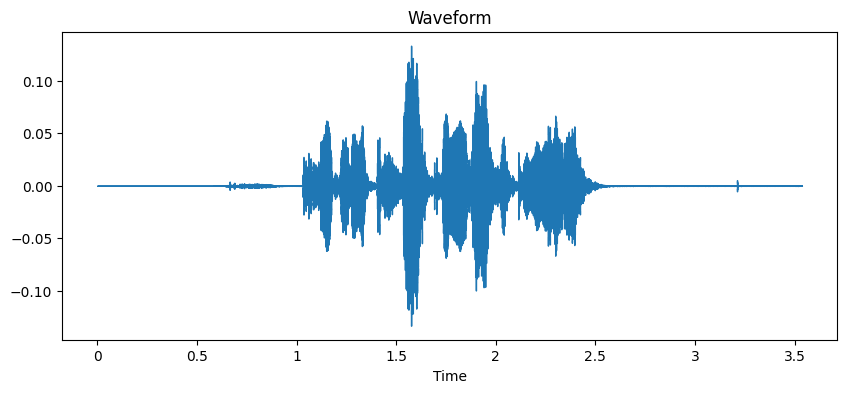

In [ ]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

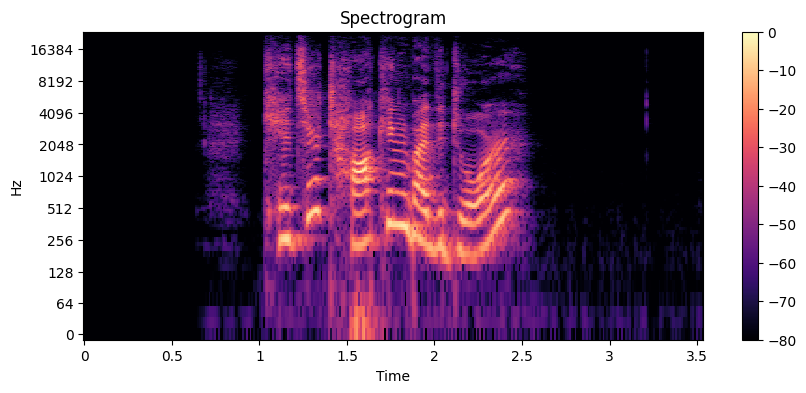

In [ ]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()
plt.title("Spectrogram")
plt.show()

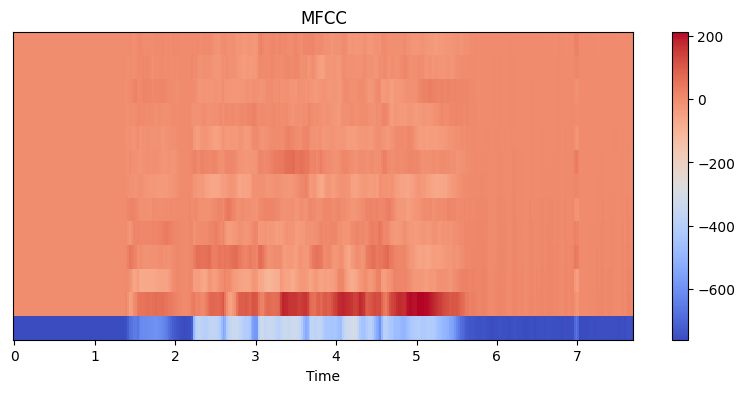

In [ ]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC")
plt.show()

In [ ]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    energy = np.mean(librosa.feature.rms(y=y))

    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch = np.mean(pitches[pitches > 0])

    features = np.hstack([mfcc, zcr, centroid, energy, pitch])
    return features

In [ ]:
X = []
y_labels = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".wav"):
            emotion = file.split("-")[2]

            if emotion == "02":   # Calm
                label = 0  # Normal
            elif emotion in ["05", "06"]:  # Angry, Fearful
                label = 1  # Stressed
            else:
                continue

            file_path = os.path.join(root, file)
            features = extract_features(file_path)

            X.append(features)
            y_labels.append(label)

X = np.array(X)
y_labels = np.array(y_labels)

print("Dataset Shape:", X.shape)

Dataset Shape: (1152, 17)


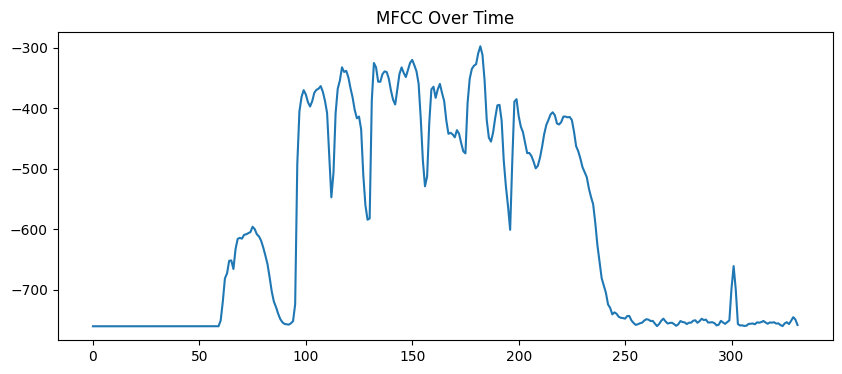

In [ ]:
mfcc_full = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=1)

plt.figure(figsize=(10,4))
plt.plot(mfcc_full.T)
plt.title("MFCC Over Time")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        75
           1       1.00      0.99      0.99       156

    accuracy                           0.99       231
   macro avg       0.99      0.99      0.99       231
weighted avg       0.99      0.99      0.99       231



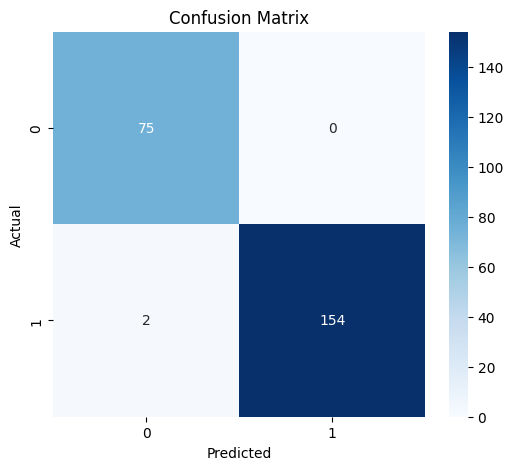

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

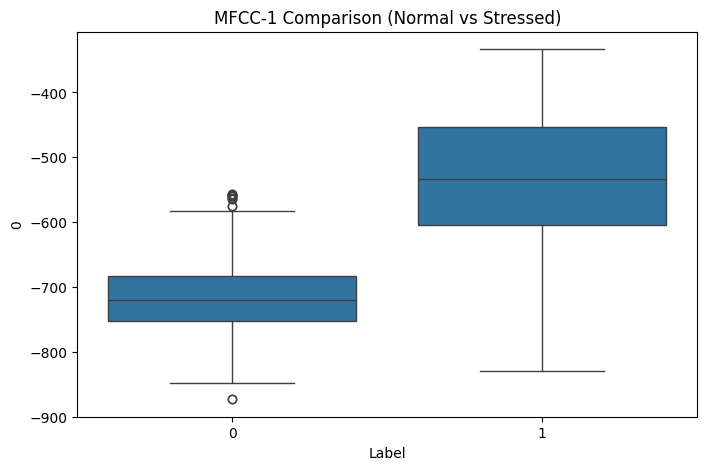

In [ ]:
df = pd.DataFrame(X)
df["Label"] = y_labels

plt.figure(figsize=(8,5))
sns.boxplot(x="Label", y=0, data=df)
plt.title("MFCC-1 Comparison (Normal vs Stressed)")
plt.show()